In [1600]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt 

In [1601]:
# Parameters

In [1602]:
C = 0.01
n_splits = 5
output_file = f'model_C={C}.bin'

In [1603]:
# Pre-processing data

In [1604]:
df = pd.read_csv('../data/ranked_matches_aoe2.csv')
df.head()

,Unnamed: 0,match_id,avg_elo,time,map,map_size,duration,p1_civ,p2_civ,winner,...,p2_Elite Caravel,p2_Elite Elephant Archer,p2_Great Wall,p2_Heavy Demolition Ship,p2_Cuman Mercenaries,p2_Madrasah,p2_Silk Road,p2_Elite Turtle Ship,game_alive,current_gametime
0,50453403_1200,50453403,1104.0,1200,Arabia,Tiny,3445,Vikings,Mayans,0,...,0,0,0,0,0,0,0,0,True,1200
1,64335748_1200,64335748,1080.0,1200,Arabia,Tiny,851,Mayans,Magyars,1,...,0,0,0,0,0,0,0,0,False,1200
2,116883036_1200,116883036,1050.0,1200,Arabia,Tiny,4737,Berbers,Slavs,1,...,0,0,0,0,0,0,0,0,True,1200
3,125287851_1200,125287851,1672.5,1200,Arabia,Tiny,2899,Vikings,Mayans,0,...,0,0,0,0,0,0,0,0,True,1200
4,107928939_1200,107928939,1135.0,1200,Arabia,Tiny,1824,Chinese,Japanese,1,...,0,0,0,0,0,0,0,0,True,1200


In [1605]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

str_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in str_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [1606]:
df.head()

,unnamed:_0,match_id,avg_elo,time,map,map_size,duration,p1_civ,p2_civ,winner,...,p2_elite_caravel,p2_elite_elephant_archer,p2_great_wall,p2_heavy_demolition_ship,p2_cuman_mercenaries,p2_madrasah,p2_silk_road,p2_elite_turtle_ship,game_alive,current_gametime
0,50453403_1200,50453403,1104.0,1200,arabia,tiny,3445,vikings,mayans,0,...,0,0,0,0,0,0,0,0,True,1200
1,64335748_1200,64335748,1080.0,1200,arabia,tiny,851,mayans,magyars,1,...,0,0,0,0,0,0,0,0,False,1200
2,116883036_1200,116883036,1050.0,1200,arabia,tiny,4737,berbers,slavs,1,...,0,0,0,0,0,0,0,0,True,1200
3,125287851_1200,125287851,1672.5,1200,arabia,tiny,2899,vikings,mayans,0,...,0,0,0,0,0,0,0,0,True,1200
4,107928939_1200,107928939,1135.0,1200,arabia,tiny,1824,chinese,japanese,1,...,0,0,0,0,0,0,0,0,True,1200


In [1607]:
# EDA

In [1608]:
df['map'].value_counts(normalize=True)

map
arabia    1.0
Name: proportion, dtype: float64

In [1609]:
df.p1_horse_collar

0         0
1         0
2         1
3         0
4         0
         ..
138897    0
138898    0
138899    0
138900    1
138901    1
Name: p1_horse_collar, Length: 138902, dtype: int64

In [1610]:
df_small = df[['avg_elo', 'duration', 'p1_civ', 'p2_civ', 'p1_villager', 'p2_villager', 'p1_militia', 
               'p2_militia', 'p1_archer', 'p2_archer', 'p1_scout_cavalry', 'p2_scout_cavalry', 
               'winner']]
df_small

,avg_elo,duration,p1_civ,p2_civ,p1_villager,p2_villager,p1_militia,p2_militia,p1_archer,p2_archer,p1_scout_cavalry,p2_scout_cavalry,winner
0,1104.0,3445,vikings,mayans,34,34,14,0,0,14,0,0,0
1,1080.0,851,mayans,magyars,24,28,3,0,0,0,0,4,1
2,1050.0,4737,berbers,slavs,36,42,0,0,0,19,6,0,1
3,1672.5,2899,vikings,mayans,59,48,5,3,8,22,0,0,0
4,1135.0,1824,chinese,japanese,43,31,2,7,7,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
138897,1236.0,1917,franks,franks,43,40,0,0,0,0,3,0,0
138898,1540.0,2525,mongols,byzantines,40,39,3,0,10,8,0,0,1
138899,870.5,4243,bulgarians,ethiopians,32,34,3,0,0,9,0,0,1
138900,1234.5,3280,turks,indians,47,38,0,0,0,0,7,6,1


In [1611]:
df_small.isnull().sum()

avg_elo             0
duration            0
p1_civ              0
p2_civ              0
p1_villager         0
p2_villager         0
p1_militia          0
p2_militia          0
p1_archer           0
p2_archer           0
p1_scout_cavalry    0
p2_scout_cavalry    0
winner              0
dtype: int64

In [1612]:
df_small.winner.value_counts(normalize=True)

winner
1    0.510849
0    0.489151
Name: proportion, dtype: float64

In [1613]:
df_small.p1_civ.value_counts(normalize=True)

p1_civ
franks         0.108314
mayans         0.061619
britons        0.058509
magyars        0.056515
ethiopians     0.055694
mongols        0.046212
lithuanians    0.041187
huns           0.036609
vikings        0.032649
bulgarians     0.029647
aztecs         0.027753
goths          0.025486
berbers        0.024550
chinese        0.024406
japanese       0.021404
celts          0.021360
tatars         0.020842
persians       0.020820
teutons        0.020727
khmer          0.020338
vietnamese     0.020331
cumans         0.019208
byzantines     0.019179
malians        0.016119
saracens       0.015990
incas          0.015342
spanish        0.015306
turks          0.014197
slavs          0.013887
burgundians    0.013859
koreans        0.012232
indians        0.010619
sicilians      0.010137
poles          0.009719
italians       0.009330
malay          0.008970
burmese        0.008632
portuguese     0.008330
bohemians      0.003974
Name: proportion, dtype: float64

In [1614]:
p1_wins = {}
p2_wins = {}

In [1615]:
p1_games = {}
p2_games = {}

In [1616]:
for i, row in df_small.iterrows():
    p1_civ = row['p1_civ']
    p2_civ = row['p2_civ']
    winner = row['winner']

    p1_games[p1_civ] = p1_games.get(p1_civ, 0) + 1
    p2_games[p2_civ] = p2_games.get(p2_civ, 0) + 1
    
    if winner == 0:
        p1_wins[p1_civ] = p1_wins.get(p1_civ, 0) + 1
    else: 
        p2_wins[p2_civ] = p2_wins.get(p2_civ, 0) + 1

In [1617]:
p1_civ_rate = {civ: (p1_wins.get(civ, 0) / p1_games[civ]) * 100 for civ in p1_games}
p2_civ_rate = {civ: (p2_wins.get(civ, 0) / p2_games[civ]) * 100 for civ in p2_games}

In [1618]:
df_small['p1_civ_rate'] = df_small['p1_civ'].map(p1_civ_rate)
df_small['p2_civ_rate'] = df_small['p2_civ'].map(p2_civ_rate)

/tmp/ipykernel_199689/2353095331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['p1_civ_rate'] = df_small['p1_civ'].map(p1_civ_rate)
/tmp/ipykernel_199689/2353095331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['p2_civ_rate'] = df_small['p2_civ'].map(p2_civ_rate)


In [1619]:
df_small[['p1_civ', 'p2_civ', 'p1_civ_rate', 'p2_civ_rate']]

,p1_civ,p2_civ,p1_civ_rate,p2_civ_rate
0,vikings,mayans,49.261301,52.281879
1,mayans,magyars,49.024419,52.708692
2,berbers,slavs,53.607038,51.776927
3,vikings,mayans,49.261301,52.281879
4,chinese,japanese,45.250737,49.914119
...,...,...,...,...
138897,franks,franks,52.608840,54.838710
138898,mongols,byzantines,48.777068,46.643783
138899,bulgarians,ethiopians,51.505585,51.363405
138900,turks,indians,46.146045,54.398311


In [1620]:
grouped_p2 = df_small.groupby('p2_civ')['p2_civ_rate'].mean().reset_index()

sorted_grouped_p2 = grouped_p2.sort_values(by='p2_civ_rate', ascending=False)
sorted_grouped_p2

,p2_civ,p2_civ_rate
1,berbers,55.522119
12,franks,54.838710
16,indians,54.398311
21,lithuanians,53.797031
14,huns,52.993030
4,bulgarians,52.938331
8,celts,52.709848
22,magyars,52.708692
38,vikings,52.440633
25,mayans,52.281879


In [1621]:
grouped_p1 = df_small.groupby('p1_civ')['p1_civ_rate'].mean().reset_index()

sorted_grouped_p1 = grouped_p1.sort_values(by='p1_civ_rate', ascending=False)
sorted_grouped_p1

,p1_civ,p1_civ_rate
1,berbers,53.607038
12,franks,52.608840
21,lithuanians,52.508303
4,bulgarians,51.505585
14,huns,51.150442
24,malians,50.379634
22,magyars,50.356688
35,teutons,49.739493
16,indians,49.491525
27,persians,49.308437


In [1622]:
total_wins = {}
total_games = {}

In [1623]:
for i, row in df_small.iterrows():
    p1_civ = row['p1_civ']
    p2_civ = row['p2_civ']
    winner = row['winner']

    total_games[p1_civ] = total_games.get(p1_civ, 0) + 1
    total_games[p2_civ] = total_games.get(p2_civ, 0) + 1
    
    if winner == 0: 
        total_wins[p1_civ] = total_wins.get(p1_civ, 0) + 1
    else:
        total_wins[p2_civ] = total_wins.get(p2_civ, 0) + 1

In [1624]:
total_civ_rate = {}

for civ in total_games:
    total_victories = total_wins.get(civ, 0)
    total_rate = (total_victories / total_games[civ]) * 100
    total_civ_rate[civ] = total_rate

In [1625]:
total_rate_df = pd.DataFrame(list(total_civ_rate.items()), columns=['civilization', 'win_rate'])
total_rate_df = total_rate_df.sort_values(by='win_rate', ascending=False)

total_rate_df

,civilization,win_rate
3,berbers,54.552206
10,franks,53.727983
22,lithuanians,53.156752
24,bulgarians,52.223434
8,huns,52.052595
36,indians,51.899171
2,magyars,51.552717
0,vikings,50.853242
1,mayans,50.688611
15,celts,50.442183


In [1626]:
# VALIDATION

In [1627]:
from sklearn.model_selection import train_test_split

In [1628]:
df_for_train = df[['avg_elo', 'duration', 'p1_civ', 'p2_civ', 'p1_villager', 'p2_villager', 'p1_militia', 
               'p2_militia', 'p1_archer', 'p2_archer', 'p1_scout_cavalry', 'p2_scout_cavalry', 
               'p1_feudal_age_time', 'p2_feudal_age_time', 'p1_house', 'p2_house',
               'p2_lumber_camp', 'p2_mining_camp', 'p1_farm', 'p2_farm', 'p1_archery_range',
               'p1_stable', 'p2_stable', 'p2_horse_collar', 
               'p1_double-bit_axe', 'p2_double-bit_axe', 'winner']]
df_for_train = pd.DataFrame(df_for_train)

In [1629]:
n = 9000

df_for_train = df_for_train.iloc[:n]
df_for_train

,avg_elo,duration,p1_civ,p2_civ,p1_villager,p2_villager,p1_militia,p2_militia,p1_archer,p2_archer,...,p2_mining_camp,p1_farm,p2_farm,p1_archery_range,p1_stable,p2_stable,p2_horse_collar,p1_double-bit_axe,p2_double-bit_axe,winner
0,1104.0,3445,vikings,mayans,34,34,14,0,0,14,...,1,16,13,0,1,0,0,0,1,0
1,1080.0,851,mayans,magyars,24,28,3,0,0,0,...,0,2,9,0,0,1,0,0,0,1
2,1050.0,4737,berbers,slavs,36,42,0,0,0,19,...,2,21,12,0,1,0,1,1,1,1
3,1672.5,2899,vikings,mayans,59,48,5,3,8,22,...,1,17,18,2,0,0,1,2,1,0
4,1135.0,1824,chinese,japanese,43,31,2,7,7,0,...,1,18,17,1,0,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,925.0,3316,teutons,mayans,41,42,1,1,0,2,...,1,11,16,0,0,0,0,0,1,1
8996,1331.0,1499,mayans,vietnamese,24,35,0,8,0,14,...,1,0,18,0,0,0,2,0,1,1
8997,1117.5,2460,tatars,tatars,49,34,0,0,21,2,...,1,19,10,2,1,0,1,1,1,0
8998,1032.0,2176,franks,franks,35,45,0,0,0,0,...,1,11,19,0,2,2,0,1,2,1


In [1630]:
df_full_train, df_test = train_test_split(df_for_train, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [1631]:
len(df_full_train), len(df_test)

(7200, 1800)

In [1632]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [1633]:
y_train = df_train.winner.values
y_val = df_val.winner.values
y_test = df_test.winner.values

In [1634]:
del df_train['winner']
del df_val['winner']
del df_test['winner']

In [1635]:
# EDA

In [1636]:
df_full_train = df_full_train.reset_index(drop=True)

In [1637]:
df_full_train.winner.value_counts(normalize=True)

winner
1    0.519167
0    0.480833
Name: proportion, dtype: float64

In [1638]:
civ_rate = df_full_train.winner.mean()
round(civ_rate, 4)

np.float64(0.5192)

In [1639]:
df_full_train

,avg_elo,duration,p1_civ,p2_civ,p1_villager,p2_villager,p1_militia,p2_militia,p1_archer,p2_archer,...,p2_mining_camp,p1_farm,p2_farm,p1_archery_range,p1_stable,p2_stable,p2_horse_collar,p1_double-bit_axe,p2_double-bit_axe,winner
0,1305.5,2026,lithuanians,franks,37,38,0,0,0,0,...,2,20,19,0,1,1,0,1,1,1
1,979.0,2832,saracens,persians,50,50,0,0,14,7,...,1,7,12,2,0,1,1,1,1,1
2,1151.0,4733,incas,ethiopians,54,42,3,9,0,10,...,1,15,18,1,0,0,0,1,1,0
3,1108.5,3498,britons,cumans,40,48,0,0,20,0,...,1,8,17,2,0,1,1,1,1,0
4,833.5,2140,ethiopians,mongols,31,33,0,0,10,0,...,2,7,6,2,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,1887.5,2366,huns,poles,41,42,0,0,0,0,...,1,17,18,0,2,2,1,1,1,1
7196,1247.5,2585,ethiopians,goths,38,28,0,18,12,0,...,1,9,8,2,0,0,0,1,1,0
7197,1214.0,3155,lithuanians,ethiopians,32,34,0,0,0,12,...,1,12,9,0,3,0,1,1,1,0
7198,924.0,1647,persians,vikings,42,28,0,7,0,0,...,1,8,7,0,0,1,0,0,1,1


In [1640]:
categorical = [
    'p1_civ', 
    'p2_civ'
]

numerical = [
    'avg_elo',
    'duration',
    'p1_villager',
    'p2_villager', 
    'p1_militia',
    'p2_militia', 
    'p1_archer',
    'p2_archer',
    'p1_scout_cavalry',
    'p2_scout_cavalry', 
    'p1_feudal_age_time', 
    'p2_feudal_age_time', 
    'p1_house', 
    'p2_house', 
    'p2_lumber_camp', 
    'p2_mining_camp', 
    'p1_farm', 
    'p2_farm', 
    'p1_archery_range',
    'p1_stable',
    'p2_stable',
    'p2_horse_collar', 
    'p1_double-bit_axe', 
    'p2_double-bit_axe'
]

In [1641]:
df_full_train[categorical].nunique()

p1_civ    39
p2_civ    39
dtype: int64

In [1642]:
# Feature Importance

In [1643]:
df_full_train.head()

,avg_elo,duration,p1_civ,p2_civ,p1_villager,p2_villager,p1_militia,p2_militia,p1_archer,p2_archer,...,p2_mining_camp,p1_farm,p2_farm,p1_archery_range,p1_stable,p2_stable,p2_horse_collar,p1_double-bit_axe,p2_double-bit_axe,winner
0,1305.5,2026,lithuanians,franks,37,38,0,0,0,0,...,2,20,19,0,1,1,0,1,1,1
1,979.0,2832,saracens,persians,50,50,0,0,14,7,...,1,7,12,2,0,1,1,1,1,1
2,1151.0,4733,incas,ethiopians,54,42,3,9,0,10,...,1,15,18,1,0,0,0,1,1,0
3,1108.5,3498,britons,cumans,40,48,0,0,20,0,...,1,8,17,2,0,1,1,1,1,0
4,833.5,2140,ethiopians,mongols,31,33,0,0,10,0,...,2,7,6,2,0,0,1,0,1,0


In [1644]:
civ_berberes_p1 = df_full_train[df_full_train.p1_civ == 'berbers'].winner.mean()
print(civ_berberes_p1)

0.48484848484848486


In [1645]:
civ_berberes_p2 = df_full_train[df_full_train.p2_civ == 'berbers'].winner.mean()
print(civ_berberes_p2)

0.5434782608695652


In [1646]:
winner_mean = df_full_train.winner.value_counts(normalize=True)
print(winner_mean)

winner
1    0.519167
0    0.480833
Name: proportion, dtype: float64


In [1647]:
print(winner_mean - civ_berberes_p1)

winner
1    0.034318
0   -0.004015
Name: proportion, dtype: float64


In [1648]:
print(winner_mean - civ_berberes_p2)

winner
1   -0.024312
0   -0.062645
Name: proportion, dtype: float64


In [1649]:
avg_elo = df_full_train.avg_elo.mean()
print(avg_elo)

1152.719375


In [1650]:
avg_elo_high = df_full_train[df_full_train.avg_elo > 1151].winner.mean()
print(avg_elo_high)

0.5127915726109857


In [1651]:
avg_elo_low = df_full_train[df_full_train.avg_elo < 1151].winner.mean()
print(avg_elo_low)

0.5231481481481481


In [1652]:
print(winner_mean - avg_elo_high)

winner
1    0.006375
0   -0.031958
Name: proportion, dtype: float64


In [1653]:
print(winner_mean - avg_elo_low)

winner
1   -0.003981
0   -0.042315
Name: proportion, dtype: float64


In [1654]:
# RISK RATIO

In [1655]:
print(civ_berberes_p1 / winner_mean)

winner
1    0.933898
0    1.008350
Name: proportion, dtype: float64


In [1656]:
print(civ_berberes_p2 / winner_mean)

winner
1    1.046828
0    1.130284
Name: proportion, dtype: float64


In [1657]:
print(avg_elo_low / winner_mean)

winner
1    1.007669
0    1.088003
Name: proportion, dtype: float64


In [1658]:
print(avg_elo_high / winner_mean)

winner
1    0.987721
0    1.066464
Name: proportion, dtype: float64


In [1659]:
from IPython.display import display

In [1660]:
winner_mean = df_full_train['winner'].mean()

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).winner.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - winner_mean 
    df_group['risk'] = df_group['mean'] / winner_mean 
    df_group.groupby('risk')
    display(df_group)
    print()
    print()

p1_civ


,mean,count,diff,risk
p1_civ,,,,
aztecs,0.483871,186,-0.035296,0.932015
berbers,0.484848,165,-0.034318,0.933898
bohemians,0.586207,29,0.067040,1.129130
britons,0.546318,421,0.027152,1.052298
bulgarians,0.453744,227,-0.065422,0.873986
burgundians,0.531915,94,0.012748,1.024555
burmese,0.594203,69,0.075036,1.144532
byzantines,0.521008,119,0.001842,1.003547
celts,0.520270,148,0.001104,1.002126




p2_civ


,mean,count,diff,risk
p2_civ,,,,
aztecs,0.568528,197,0.049361,1.095078
berbers,0.543478,184,0.024312,1.046828
bohemians,0.419355,31,-0.099812,0.807746
britons,0.482143,448,-0.037024,0.928686
bulgarians,0.524229,227,0.005062,1.009751
burgundians,0.443299,97,-0.075868,0.853866
burmese,0.529412,68,0.010245,1.019734
byzantines,0.524138,145,0.004971,1.009575
celts,0.566667,150,0.047500,1.091493


In [1661]:
numerical

['avg_elo',
 'duration',
 'p1_villager',
 'p2_villager',
 'p1_militia',
 'p2_militia',
 'p1_archer',
 'p2_archer',
 'p1_scout_cavalry',
 'p2_scout_cavalry',
 'p1_feudal_age_time',
 'p2_feudal_age_time',
 'p1_house',
 'p2_house',
 'p2_lumber_camp',
 'p2_mining_camp',
 'p1_farm',
 'p2_farm',
 'p1_archery_range',
 'p1_stable',
 'p2_stable',
 'p2_horse_collar',
 'p1_double-bit_axe',
 'p2_double-bit_axe']

In [1662]:
for n in numerical:
    print(n)
    df_group_elo = df_full_train.groupby(n).winner.agg(['mean', 'count'])
    df_group_elo['diff'] = df_group_elo['mean'] - winner_mean 
    df_group_elo['risk'] = df_group_elo['mean'] / winner_mean 
    df_group_elo.groupby('risk')
    display(df_group_elo)
    print()
    print()

avg_elo


,mean,count,diff,risk
avg_elo,,,,
764.5,1.0,1,0.480833,1.926164
784.0,0.0,1,-0.519167,0.000000
790.5,0.0,1,-0.519167,0.000000
792.0,0.0,2,-0.519167,0.000000
795.0,1.0,1,0.480833,1.926164
...,...,...,...,...
2383.0,0.0,1,-0.519167,0.000000
2399.5,0.0,1,-0.519167,0.000000
2456.5,0.0,2,-0.519167,0.000000




duration


,mean,count,diff,risk
duration,,,,
1,0.363636,11,-0.155530,0.700423
2,0.000000,5,-0.519167,0.000000
3,0.166667,6,-0.352500,0.321027
4,0.666667,3,0.147500,1.284109
5,0.285714,7,-0.233452,0.550332
...,...,...,...,...
7366,1.000000,1,0.480833,1.926164
8514,0.000000,1,-0.519167,0.000000
8690,0.000000,1,-0.519167,0.000000




p1_villager


...

,mean,count,diff,risk
p2_horse_collar,,,,
0,0.500139,3587,-0.019027,0.963350
1,0.535229,3165,0.016062,1.030939
2,0.569343,411,0.050176,1.096648
3,0.428571,28,-0.090595,0.825499
4,0.333333,6,-0.185833,0.642055
5,0.000000,1,-0.519167,0.000000
6,1.000000,1,0.480833,1.926164
8,1.000000,1,0.480833,1.926164




p1_double-bit_axe


,mean,count,diff,risk
p1_double-bit_axe,,,,
0,0.584407,1552,0.065241,1.125664
1,0.504597,4895,-0.014570,0.971936
2,0.472384,688,-0.046783,0.909888
3,0.583333,60,0.064167,1.123596
4,0.250000,4,-0.269167,0.481541
7,0.000000,1,-0.519167,0.000000




p2_double-bit_axe


,mean,count,diff,risk
p2_double-bit_axe,,,,
0,0.460224,1521,-0.058943,0.886466
1,0.534283,4915,0.015116,1.029116
2,0.537589,705,0.018422,1.035484
3,0.591837,49,0.072670,1.139974
4,0.500000,6,-0.019167,0.963082
5,0.500000,2,-0.019167,0.963082
6,0.000000,1,-0.519167,0.000000
7,0.000000,1,-0.519167,0.000000


In [1663]:
# Feature importance: Mutual Information

In [1664]:
from sklearn.metrics import mutual_info_score

In [1665]:
mutual_info_score(df_full_train.winner, df_full_train.avg_elo)

/home/nicolas/ml-aoe2/venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


np.float64(0.1543590258705682)

In [1666]:
mutual_info_score(df_full_train.winner, df_full_train.avg_elo)

/home/nicolas/ml-aoe2/venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received binary values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


np.float64(0.1543590258705682)

In [1667]:
mutual_info_score(df_full_train.winner, df_full_train.p2_civ)

np.float64(0.003224825814804348)

In [1668]:
mutual_info_score(df_full_train.winner, df_full_train.duration)

np.float64(0.3077126213744582)

In [1669]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.winner)

In [1670]:
mi = df_full_train[categorical + numerical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

/home/nicolas/ml-aoe2/venv/lib/python3.12/site-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


duration              0.307713
avg_elo               0.154359
p2_feudal_age_time    0.041319
p1_feudal_age_time    0.038111
p2_villager           0.013239
p1_villager           0.012468
p1_farm               0.009620
p2_farm               0.008763
p2_archer             0.008641
p1_archer             0.006961
p1_house              0.006018
p2_house              0.005720
p2_stable             0.004885
p1_stable             0.004128
p2_scout_cavalry      0.004101
p2_civ                0.003225
p1_civ                0.003062
p2_mining_camp        0.002984
p2_militia            0.002937
p1_double-bit_axe     0.002811
p1_scout_cavalry      0.002709
p2_lumber_camp        0.002686
p1_archery_range      0.002215
p1_militia            0.002135
p2_double-bit_axe     0.002125
p2_horse_collar       0.001284
dtype: float64

In [1671]:
# Feature Importance: Correlation

In [1672]:
print(df_full_train.duration.max())

9777


In [1673]:
df_full_train[numerical].corrwith(df_full_train.winner).abs()

avg_elo               0.008397
duration              0.018804
p1_villager           0.038588
p2_villager           0.081624
p1_militia            0.013904
p2_militia            0.015969
p1_archer             0.070641
p2_archer             0.071916
p1_scout_cavalry      0.046988
p2_scout_cavalry      0.056421
p1_feudal_age_time    0.078594
p2_feudal_age_time    0.018013
p1_house              0.011999
p2_house              0.067609
p2_lumber_camp        0.040814
p2_mining_camp        0.000894
p1_farm               0.077861
p2_farm               0.110036
p1_archery_range      0.005920
p1_stable             0.072414
p2_stable             0.091082
p2_horse_collar       0.036660
p1_double-bit_axe     0.062577
p2_double-bit_axe     0.048806
dtype: float64

In [1674]:
from sklearn.feature_extraction import DictVectorizer

In [1675]:
categorical_columns = df_full_train.select_dtypes(include=['object']).columns

categorical_data = df_full_train[categorical_columns].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
categorical_transformed = dv.fit_transform(categorical_data)

df_categorical_transformed = pd.DataFrame(categorical_transformed, columns=dv.get_feature_names_out(categorical_columns))

In [1676]:
df_numerical = df_full_train.select_dtypes(include=['number'])  

df_full_transformed = pd.concat([df_numerical, df_categorical_transformed], axis=1)

In [1677]:
correlation = df_full_transformed.corrwith(df_full_train['winner']).abs().sort_values(ascending=False)
correlation

winner                1.000000
p2_farm               0.110036
p2_stable             0.091082
p2_villager           0.081624
p1_feudal_age_time    0.078594
                        ...   
p1_civ=byzantines     0.000478
p2_civ=saracens       0.000412
p1_civ=celts          0.000320
p1_civ=cumans         0.000093
p2_civ=japanese       0.000093
Length: 103, dtype: float64

In [1678]:
# One-Hot Encoding

In [1679]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [1680]:
dv = DictVectorizer(sparse=False)

In [1681]:
x_train = dv.fit_transform(train_dicts)

In [1682]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [1683]:
x_val = dv.transform(val_dicts)

In [1684]:
# Training Model

In [1685]:
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing

In [1686]:
scaler = preprocessing.StandardScaler().fit(x_train)
scaler

StandardScaler()

In [1687]:
x_scaled = scaler.transform(x_train)

In [1688]:
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [1689]:
model.intercept_[0]

np.float64(-0.37386211618913895)

In [1690]:
y_pred = model.predict_proba(x_val)[:, 1]

In [1691]:
y_pred
print(y_pred)

[0.64920652 0.76968022 0.46364032 ... 0.49604789 0.85243781 0.35362378]


In [1692]:
winner_decision = (y_pred > 0.5).astype(float)

In [1693]:
winner_decision

array([1., 1., 0., ..., 0., 1., 0.], shape=(1800,))

In [1694]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import KFold

In [1695]:
accuracy = accuracy_score(y_val, winner_decision)
print(f'Acurácia: {accuracy:.4f}')

Acurácia: 0.6283


In [1696]:
# Descision Tree

In [1697]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

In [1698]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [1699]:
y_pred = dt.predict_proba(x_train)[:, 1]
roc_auc_score(y_train, y_pred)

np.float64(1.0)

In [1700]:
y_pred = dt.predict_proba(x_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.5798089619259091)

In [1701]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(x_train, y_train)

y_pred = dt.predict_proba(x_train)[:, 1]
auc = roc_auc_score(y_train, y_pred)
print('train auc: %.3f' % auc)

y_pred = dt.predict_proba(x_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val auc: %.3f' % auc)

train auc: 0.583
val auc: 0.581


In [1702]:
# Tuning Parameters

In [1703]:
dt = DecisionTreeClassifier(max_depth=6)
dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=6)

In [1704]:
y_pred = dt.predict_proba(x_val)[:, 1]

In [1705]:
roc_auc_score(y_val, y_pred)

np.float64(0.6239256271913991)

In [1706]:
for depth in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(x_train, y_train)
    y_pred = dt.predict_proba(x_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print('%4s -> %.3f' % (depth, auc))

   1 -> 0.548
   2 -> 0.581
   3 -> 0.600
   4 -> 0.620
   5 -> 0.616
   6 -> 0.623
  10 -> 0.590
  15 -> 0.572
  20 -> 0.560
None -> 0.557


In [1707]:
# Random Forest

In [1708]:
from sklearn.ensemble import RandomForestClassifier

In [1709]:
rf = RandomForestClassifier(n_estimators=10)
rf.fit(x_train, y_train)
y_pred = rf.predict_proba(x_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.6690078680190494)

In [1710]:
aucs = []

for i in range(100):
    rf = RandomForestClassifier(n_estimators=10)
    rf.fit(x_train, y_train)
    y_pred = rf.predict_proba(x_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    aucs.append(auc)

auc_mean = np.mean(aucs)
auc_std = np.std(aucs)

print('%.3f +- %.3f' % (auc_mean, auc_std))
print('%.3f -- %.3f' % (auc_mean -  auc_std, auc_mean + auc_std))

0.639 +- 0.011
0.628 -- 0.650


In [1711]:
df['winner'].value_counts(normalize=True)

winner
1    0.510849
0    0.489151
Name: proportion, dtype: float64

In [1712]:
civ_winrates = df.groupby('p1_civ')['winner'].mean()
df['p1_civ_winrate'] = df['p1_civ'].map(civ_winrates)
df['p2_civ_winrate'] = df['p2_civ'].map(civ_winrates)

In [1713]:
df['civ_matchup'] = df['p1_civ'] + "_" + df['p2_civ']
df = pd.get_dummies(df, columns=['civ_matchup'])

In [1714]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(x_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [1715]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(x_scaled, y_train)

print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [1716]:
rf = RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=100)
rf.fit(x_train, y_train)
y_pred = rf.predict_proba(x_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.702487747946452)

In [1717]:

# Tuning Random Forest

In [1718]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(x_train, y_train)

    y_pred = rf.predict_proba(x_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [1719]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'auc'])

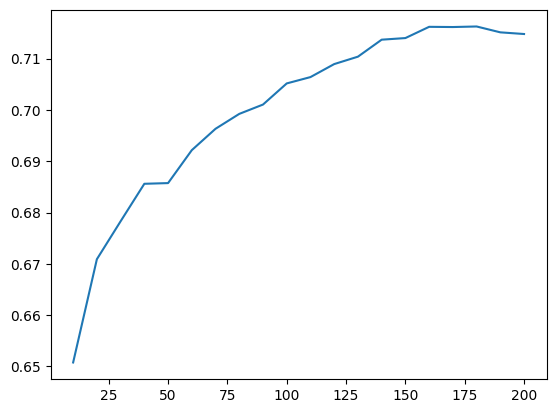

In [1720]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [1721]:
scores = []

for d in [5, 10, 15, 20, 25, 30]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        
        rf.fit(x_train, y_train)

        y_pred = rf.predict_proba(x_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [1722]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.644454
1,5,20,0.661810
2,5,30,0.665527
3,5,40,0.672885
4,5,50,0.673357


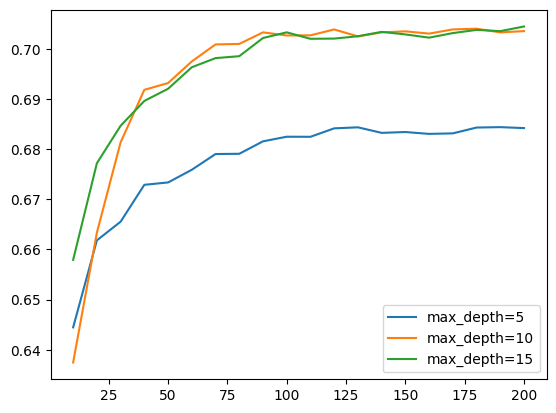

In [1723]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             label='max_depth=%d' % d)

plt.legend()

In [1724]:
max_depth = 15

In [1725]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=1)
        
        rf.fit(x_train, y_train)

        y_pred = rf.predict_proba(x_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [1726]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.657913
1,1,20,0.677182
2,1,30,0.684661
3,1,40,0.689614
4,1,50,0.692036


In [1727]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]
list(zip(min_samples_leaf_values, colors))

[(1, 'black'), (3, 'blue'), (5, 'orange'), (10, 'red'), (50, 'grey')]

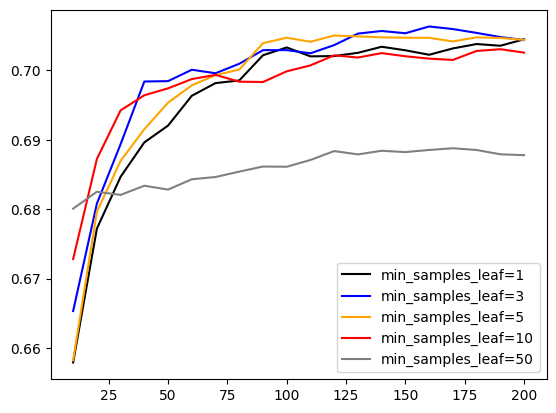

In [1728]:
colors = ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1, 3, 5, 10, 50]

for s, col in zip(min_samples_leaf_values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [1729]:
min_samples_leaf = 5

In [1730]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1,
                            n_jobs=-1)

rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                       random_state=1)

In [1731]:
# XGBoost

In [1732]:

import xgboost as xgb

In [1733]:
features = dv.get_feature_names_out()
features_list = features.tolist()
dtrain = xgb.DMatrix(x_train, label=y_train, feature_names=features_list)
dval = xgb.DMatrix(x_val, label=y_val, feature_names=features_list)

In [1734]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=10)

In [1735]:
y_pred = model.predict(dval)

In [1736]:
roc_auc_score(y_val, y_pred)

np.float64(0.6852038217505477)

In [1737]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [1738]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [1739]:
s = output.stdout

In [1740]:
print(s)

[0]	train-auc:0.71438	val-auc:0.63378
[5]	train-auc:0.82812	val-auc:0.67628
[10]	train-auc:0.86914	val-auc:0.68178
[15]	train-auc:0.89649	val-auc:0.68240
[20]	train-auc:0.91723	val-auc:0.68817
[25]	train-auc:0.92940	val-auc:0.69185
[30]	train-auc:0.94182	val-auc:0.68922
[35]	train-auc:0.94797	val-auc:0.68873
[40]	train-auc:0.95717	val-auc:0.69248
[45]	train-auc:0.96597	val-auc:0.69160
[50]	train-auc:0.97173	val-auc:0.69338
[55]	train-auc:0.97807	val-auc:0.69447
[60]	train-auc:0.98304	val-auc:0.69436
[65]	train-auc:0.98620	val-auc:0.69606
[70]	train-auc:0.98838	val-auc:0.69748
[75]	train-auc:0.99151	val-auc:0.69313
[80]	train-auc:0.99276	val-auc:0.69131
[85]	train-auc:0.99431	val-auc:0.69076
[90]	train-auc:0.99581	val-auc:0.69214
[95]	train-auc:0.99651	val-auc:0.69203
[100]	train-auc:0.99748	val-auc:0.69332
[105]	train-auc:0.99826	val-auc:0.69170
[110]	train-auc:0.99842	val-auc:0.69270
[115]	train-auc:0.99879	val-auc:0.69523
[120]	train-auc:0.99915	val-auc:0.69339
[125]	train-auc:0.9993

In [1741]:
line = s.split('\n')[0]

In [1742]:
num_iter, train_auc, val_auc = line.split('\t')

In [1743]:
int(num_iter.strip('[]'))

0

In [1744]:
float(train_auc.split(':')[1])

0.71438

In [1745]:
float(val_auc.split(':')[1])

0.63378

In [1746]:
def parse_xbg_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [1747]:
df_score = parse_xbg_output(output)

In [1748]:
df_score

,num_iter,train_auc,val_auc
0,0,0.71438,0.63378
1,5,0.82812,0.67628
2,10,0.86914,0.68178
3,15,0.89649,0.68240
4,20,0.91723,0.68817
5,25,0.92940,0.69185
6,30,0.94182,0.68922
7,35,0.94797,0.68873
8,40,0.95717,0.69248
9,45,0.96597,0.69160


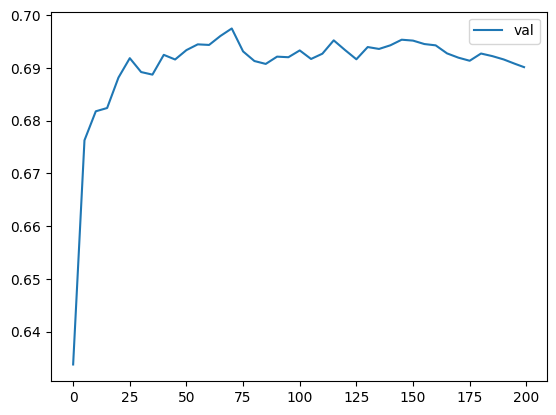

In [1749]:
# plt.plot(df_score.num_iter. df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

In [1750]:
scores = {}

In [1751]:
%%capture output

xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [1752]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xbg_output(output)
key

'min_child_weight=30'

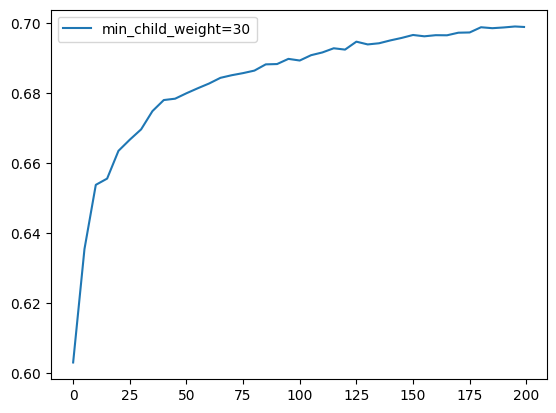

In [1753]:
for min_child_weight, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)
    plt.legend()

In [1754]:
# Final Model

In [1755]:
rf = RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=100)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=5)

In [1756]:
y_pred = dt.predict_proba(x_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.5565683864873819)

In [1757]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=15,
                            min_samples_leaf=5,
                            random_state=1)

rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, n_estimators=200,
                       random_state=1)

In [1758]:
y_pred = rf.predict_proba(x_val)[:, 1]
roc_auc_score(y_val, y_pred)

np.float64(0.7043793364357033)

In [1759]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 5,
    'min_child_weight': 3,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=175) 

In [1760]:
y_pred = model.predict(dval)
roc_auc_score(y_val, y_pred)

np.float64(0.7020439046342682)

In [1761]:
df_full_train = df_full_train.reset_index(drop=True)

In [1762]:
y_full_train = (df_full_train.winner == 1).values

In [1763]:
del df_full_train['winner']

In [1764]:
dicts_full_train = df_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [1765]:

features = dv.get_feature_names_out()
features_list = features.tolist()
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train,
                         feature_names=features_list)

dtest = xgb.DMatrix(X_test, feature_names=features_list)

In [1766]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dfulltrain, num_boost_round=175) 

In [1767]:
y_pred = model.predict(dtest)

In [1768]:
roc_auc_score(y_test, y_pred)

np.float64(0.7118014569699963)